Data Cleaning and Visualization Using R - Febuary 14, 2026 - angbur5378

In [1]:
library(readxl) 
library(dplyr) 
library(ggplot2) 
library(tidyr) 
library(stringr) 
library(corrplot) 


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


corrplot 0.95 loaded



In [2]:
file_path <- "C:/Files/Excel/DA_PythonR/AirBnBSummary_v2(1).xlsx" 
df <- read_excel(file_path) 
head(df) 

id,host_id,host_name,neighbourhood,room_type,price,minimum_nights,number_of_reviews,availability_365,<StudentID>
<dbl>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
7909479,41706311,David,Downtown,Entire home/apt,107,30,27,365,angbur5378
15966488,103700433,Erin,Downtown,Entire home/apt,100,1,250,74,angbur5378
19859814,103700433,Erin,Downtown,Entire home/apt,100,1,309,79,angbur5378
21071138,22992627,Joseph,Downtown,Entire home/apt,100,2,144,338,angbur5378
21712505,103700433,Erin,Downtown,Entire home/apt,100,1,178,68,angbur5378
25771375,140728885,Rick,Downtown,Entire home/apt,95,2,216,246,angbur5378


In [3]:
df_cleaned <- df %>% distinct() 

In [4]:
sum(duplicated(df_cleaned))

[1] 0

In [5]:
colnames(df) <- colnames(df) %>% 
str_to_lower() %>% 
str_trim() 

In [6]:
colSums(is.na(df))

id           host_id         host_name     neighbourhood 
                0                 0                 0                 0 
        room_type             price    minimum_nights number_of_reviews 
                0                 4                 0                 0 
 availability_365       <studentid> 
                5                 0

In [7]:
df <- df %>% 
mutate(across(where(is.numeric), ~ ifelse(is.na(.), median(., na.rm = TRUE), .))) 

In [8]:
colnames(df)

[1] "id"                "host_id"           "host_name"        
 [4] "neighbourhood"     "room_type"         "price"            
 [7] "minimum_nights"    "number_of_reviews" "availability_365" 
[10] "<studentid>"

In [9]:
Q1 <- quantile(df$price, 0.25) 
Q3 <- quantile(df$price, 0.75) 
IQR <- Q3 - Q1 
df_cleaned <- df %>% 
filter(price >= Q1 - 1.5 * IQR, price <= Q3 + 1.5 * IQR) 

In [10]:
summary(df_cleaned$price)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   20.0    82.0   110.0   124.2   159.0   308.0 

In [15]:
output_path <- "C:/Files/Excel/DA_PythonR/AirBnBSummary_Cleaned(1).csv" 
write.csv(df_cleaned, output_path, row.names = FALSE) 

In [18]:
total_listings <- nrow(df_cleaned) 
min_price <- min(df_cleaned$price) 
max_price <- max(df_cleaned$price) 
mean_price <- mean(df_cleaned$price) 
median_reviews <- median(df_cleaned$number_of_reviews) 
mode_min_nights <- names(sort(table(df_cleaned$minimum_nights), decreasing = TRUE))[1] 
std_price <- sd(df_cleaned$price) 
correlation <- cor(df_cleaned$price, df_cleaned$availability_365) 

cat("Total listings:", total_listings, "\n") 
cat("Minimum price:", min_price, "\n") 
cat("Maximum price:", max_price, "\n") 
cat("Mean price:", mean_price, "\n") 
cat("Median number of reviews:", median_reviews, "\n") 
cat("Mode of minimum nights:", mode_min_nights, "\n") 
cat("Standard deviation of price:", std_price, "\n") 
cat("Correlation between price and availability_365:", correlation, "\n") 

Total listings: 1661 
Minimum price: 20 
Maximum price: 308 
Mean price: 124.189 
Median number of reviews: 20 
Mode of minimum nights: 1 
Standard deviation of price: 61.57787 
Correlation between price and availability_365: 0.1064095 


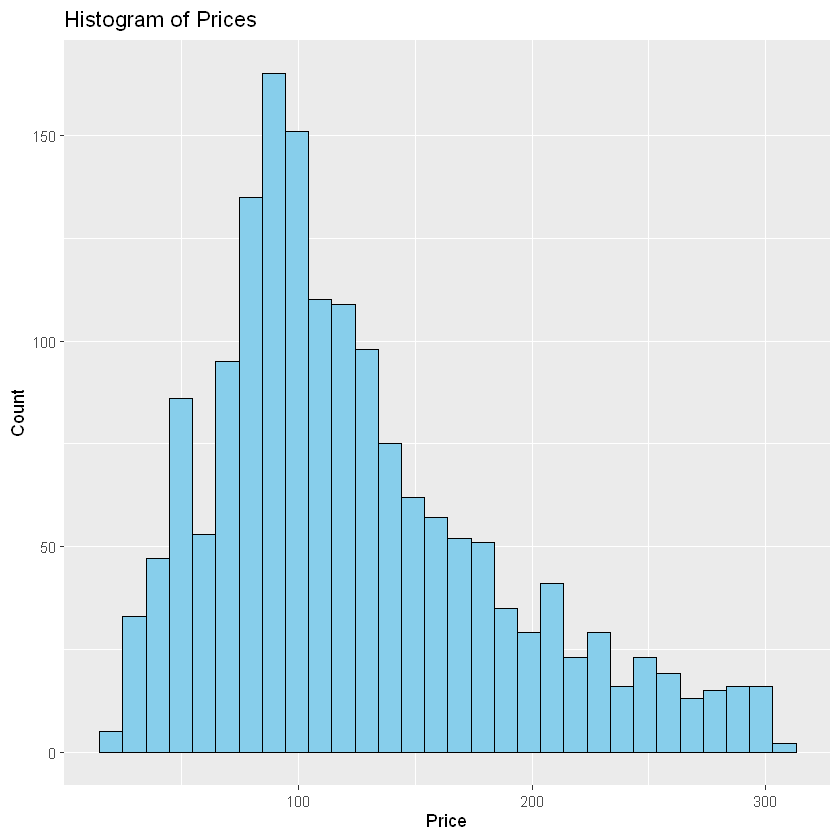

In [19]:
ggplot(df_cleaned, aes(x = price)) + 
geom_histogram(bins = 30, fill = "skyblue", color = "black") + 
labs(title = "Histogram of Prices", x = "Price", y = "Count") 

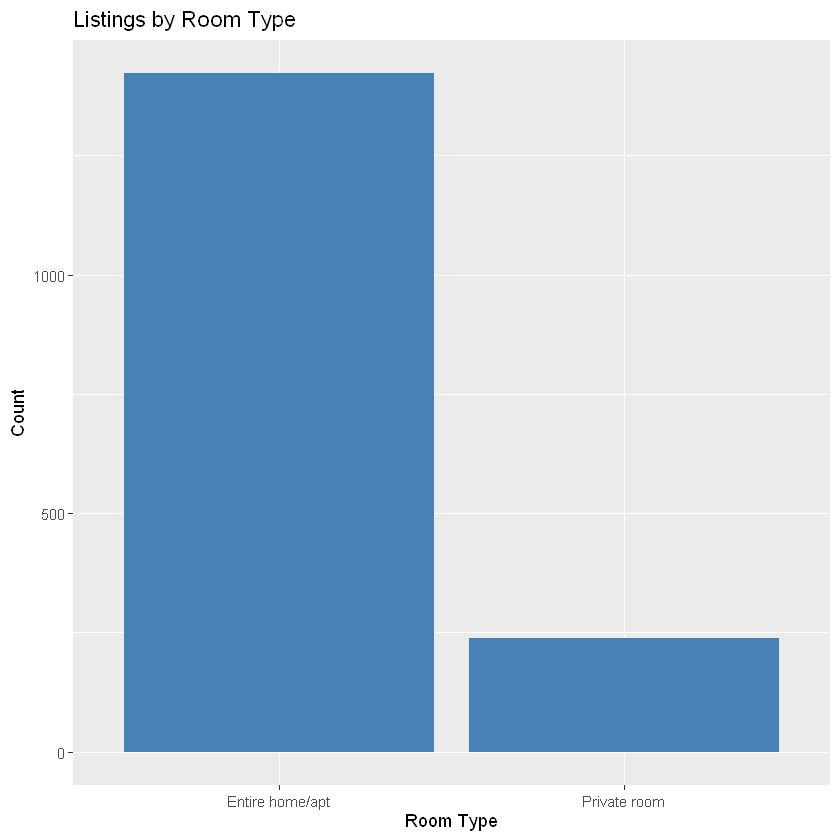

In [20]:
ggplot(df_cleaned, aes(x = room_type)) + 
geom_bar(fill = "steelblue") + 
labs(title = "Listings by Room Type", x = "Room Type", y = "Count") 

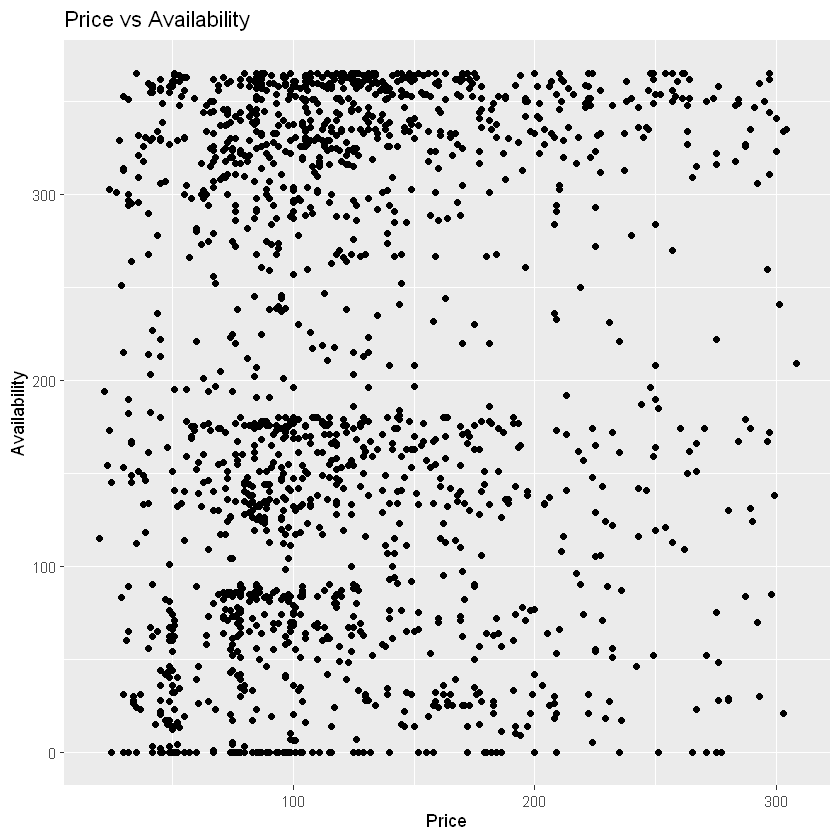

In [21]:
ggplot(df_cleaned, aes(x = price, y = availability_365)) + geom_point() + 
labs(title = "Price vs Availability", x = "Price", y = "Availability") 

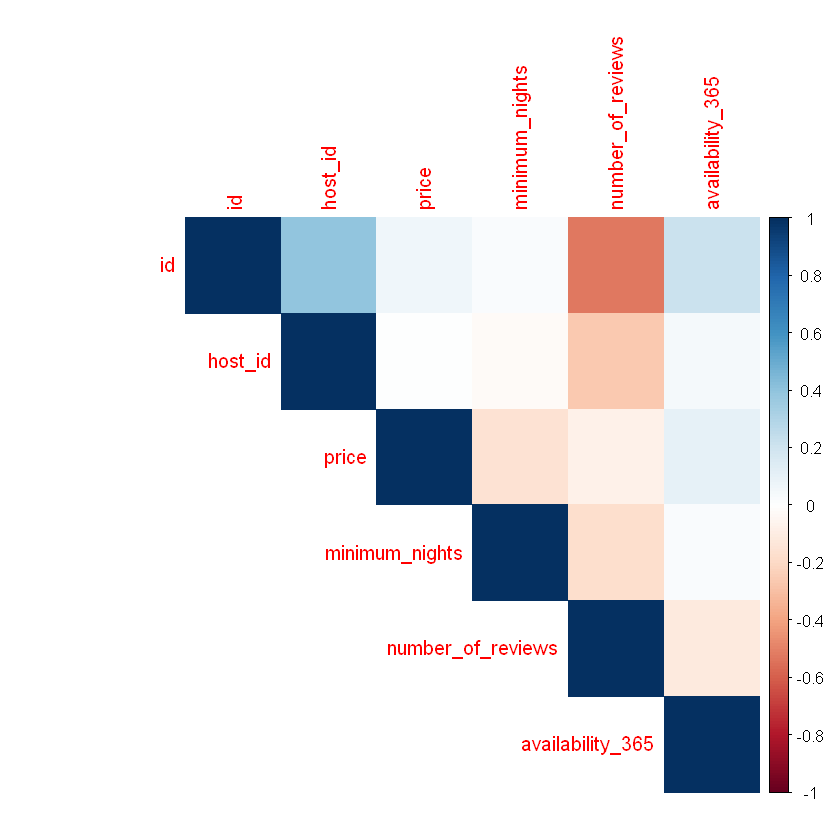

In [22]:
corr_matrix <- cor(df_cleaned %>% select(where(is.numeric))) 
corrplot(corr_matrix, method = "color", type = "upper") 